# `script01_analises_preliminares` — versão Python / PyTorch

Conversão do script MATLAB `script01_analises_preliminares.m` para Python
usando **PyTorch** com suporte automático a CPU/GPU.

**Contexto biológico.** O experimento parte de uma matriz binária de
expressão gênica (≈40 000 células × N genes). São selecionados os
**5 000 genes mais frequentes** e cada célula é representada por um
vetor SWeeP de **600 dimensões** via projeção `W0 · R5k`, onde `R5k`
é a base ortonormal **rSWeeP** (AIBIALab, https://aibialab.github.io/rSWeeP.html).
A memória associativa armazena os perfis **binários** de cada tipo de
tecido; o espaço SWeeP é usado para clusterizar e escolher protótipos.

**Mudanças importantes em relação ao original:**

* `hopf_tr` / `hopf_ts` foram substituídos por uma **Modern Hopfield Network**
  (Ramsauer et al. 2020 — *Hopfield Networks is All You Need*). Essa rede
  tem capacidade de armazenamento exponencial em vez de linear, aceita
  padrões contínuos e a recuperação é equivalente a um passo de *attention*
  (`softmax(β · Ξ · ξ) · Ξᵀ`).
* As funções auxiliares (`princomp_`, `closervects`, `contaocorr`, `sorti`,
  `mat2celllines`, `wsort`, `indexa`) foram reimplementadas em Python
  **fiéis aos arquivos `.m` originais**. Pontos importantes:
  - `princomp_` chama `pca(W, 'Centered', false, 'Algorithm', 'svd')` — ou
    seja, **não centra** os dados antes do SVD.
  - `wsort` faz **embaralhamento aleatório de linhas** (não ordena por
    conteúdo), via `[~, id] = sort(rand(N,1)); W = W(id,:)`.
  - `closervects` aceita query como vetor(es) (toma média se múltiplos)
    ou como índices em W; distância padrão é Euclidiana, mas suporta
    Lk-norm.
* Os tempos longos do MATLAB (`~12h` para `hopf_ts`) caem para minutos
  com a Modern Hopfield + GPU.


## 1. Imports e detecção de dispositivo

In [1]:
import os
import time
import numpy as np
import scipy.io as sio
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.cluster import KMeans

# Reprodutibilidade
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Detecta GPU automaticamente
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.cuda.manual_seed_all(SEED) 




Usando dispositivo: cpu


NameError: name 'gjjjjjj' is not defined

## 2. Funções auxiliares (fiéis aos `.m` originais)

Cada função abaixo replica exatamente o comportamento do `.m`
correspondente. Os arquivos `closervects.m`, `contaocorr.m`, `indexa.m`,
`mat2celllines.m`, `princomp_.m`, `sorti.m` e `wsort.m` foram inspecionados
linha a linha.


In [2]:
def sorti(x, mode="ascend"):
    """sorti.m: retorna apenas os índices que ordenam x.
    `mode="ascend"` (padrão) ou `"descend"`."""
    x = np.asarray(x).ravel()
    idx = np.argsort(x)
    if str(mode).lower().startswith("desc"):
        idx = idx[::-1]
    return idx.copy()


def princomp_(W):
    """princomp_.m: equivalente a `pca(W, Centered=false, Algorithm=svd)`.
    Retorna a matriz de loadings (d x d) com os componentes nas COLUNAS,
    em ordem decrescente de variância explicada.
    *Sem centralização* — o SVD é aplicado diretamente em W."""
    W = np.asarray(W, dtype=np.float64)
    _, _, Vt = np.linalg.svd(W, full_matrices=False)
    return Vt.T  # colunas = componentes principais


def closervects(W, Wi, k, distance="euclidean"):
    """closervects.m: índices dos k vetores em W mais próximos de Wi.

    Wi pode ser:
      - vetor(es) com a mesma dimensão das linhas de W -> toma a média;
      - vetor de índices em W -> busca em torno da média de W[indices].

    `distance` aceita "euclidean" (padrão) ou um número (Lk-norm)."""
    W = np.asarray(W, dtype=np.float64)
    Wi = np.asarray(Wi, dtype=np.float64)
    if Wi.ndim == 1:
        Wi = Wi[None, :]
    nn, mm = W.shape
    p, q = Wi.shape

    if q == mm:
        query = Wi.mean(axis=0)                # vetores -> média
    else:
        idx = Wi.ravel().astype(int) - 1       # índices 1-based -> 0-based
        query = W[idx].mean(axis=0)

    if isinstance(distance, str) and distance.lower() == "euclidean":
        diff = W - query[None, :]
        u = np.sqrt(np.einsum("ij,ij->i", diff, diff))
    else:
        kp = float(distance)
        diff = np.abs(W - query[None, :])
        u = np.sum(diff ** kp, axis=1)
        if kp >= 1:
            u = u ** (1.0 / kp)

    ii = np.argsort(u)[:k]
    return int(ii[0]) if k == 1 else ii


def contaocorr(v, ordby_max=True):
    """contaocorr.m: conta ocorrências de cada valor distinto em v.
    Retorna matriz [valor, contagem]:
      - ordenada por contagem decrescente se `ordby_max=True` (padrão);
      - ordenada por valor crescente se `ordby_max=False`."""
    v = np.asarray(v).ravel()
    vals, counts = np.unique(v, return_counts=True)
    if ordby_max:
        order = np.argsort(-counts, kind="stable")
    else:
        order = np.argsort(vals)
    return np.column_stack([vals[order], counts[order]])


def mat2celllines(M):
    """mat2celllines.m: devolve M como lista de linhas (vetores 1D)."""
    M = np.asarray(M)
    return [M[i] for i in range(M.shape[0])]


def wsort(W, return_perm=False, rng=None):
    """wsort.m: EMBARALHA as linhas de W aleatoriamente.
    Equivalente a:
        [~, id] = sort(rand(N,1));  W = W(id, :);
    Não confunda com sort por conteúdo!"""
    W = np.asarray(W)
    if rng is None:
        rng = np.random.default_rng()
    perm = rng.permutation(W.shape[0])
    out = W[perm]
    return (out, perm) if return_perm else out


def indexa(X, xinds):
    """indexa.m: equivalente a X(xinds) do MATLAB.
    Aceita também a string 'SECOND' (retorna o segundo elemento)."""
    X = np.asarray(X)
    if isinstance(xinds, str):
        if xinds.upper() == "SECOND":
            return X.ravel()[1] if X.size > 1 else np.array([])
        raise NotImplementedError(
            f"indexa: modo string '{xinds}' não usado no script — não implementado."
        )
    inds = np.asarray(list(xinds) if hasattr(xinds, "__iter__") else [xinds],
                      dtype=int).ravel() - 1
    if X.ndim == 1:
        return X[inds]
    return X[inds]


## 3. Modern Hopfield Network

Substitui `hopf_tr` (treino) e `hopf_ts` (teste) do script original.

**Regra de armazenamento (training):** simplesmente guardar os padrões.
Não há treinamento iterativo — diferente da regra de Hebb da rede clássica.

**Regra de recuperação (retrieval):** dado um *query* `ξ`, atualiza com

$$\xi_{\text{novo}} = \Xi^{\top} \, \mathrm{softmax}\!\big(\beta \, \Xi \, \xi\big)$$

onde `Ξ` (N × d) tem os padrões nas linhas e `β` é a temperatura inversa
(β grande → recupera o padrão mais próximo; β pequeno → mistura).

Para padrões binários convertemos `{0, 1} → {-1, +1}` antes da
recuperação e voltamos para `{0, 1}` no final, o que estabiliza muito
a dinâmica.


In [3]:
class ModernHopfieldNetwork(nn.Module):
    """Rede de Hopfield Moderna (Ramsauer et al., 2020).

    Parameters
    ----------
    beta : float
        Temperatura inversa do softmax. Valores típicos: 1-32.
        Quanto maior, mais 'winner-takes-all'.
    n_iters : int
        Número de iterações da regra de atualização (1 já costuma bastar).
    binary : bool
        Se True, assume entradas/saídas em {0,1} e usa internamente
        a representação bipolar {-1,+1}.
    threshold : float
        Limiar para binarizar a saída quando binary=True.
    """

    def __init__(self, beta=8.0, n_iters=1, binary=True, threshold=0.0):
        super().__init__()
        self.beta = beta
        self.n_iters = n_iters
        self.binary = binary
        self.threshold = threshold
        self.register_buffer("patterns", torch.empty(0))

    # -------------------------- treino --------------------------
    def store(self, patterns):
        """Armazena os padrões (equivalente a `hopf_tr`)."""
        P = torch.as_tensor(np.asarray(patterns), dtype=torch.float32)
        if self.binary:
            P = 2.0 * P - 1.0  # {0,1} -> {-1,+1}
        self.patterns = P.to(self.patterns.device if self.patterns.numel()
                             else torch.device("cpu"))
        return self

    # ------------------------- recuperação ----------------------
    @torch.no_grad()
    def retrieve(self, queries, batch_size=2048):
        """Recupera padrões a partir das queries (equivalente a `hopf_ts`)."""
        if self.patterns.numel() == 0:
            raise RuntimeError("Chame .store(patterns) antes de .retrieve().")

        Xi = self.patterns                               # (N, d)
        Q = torch.as_tensor(np.asarray(queries), dtype=torch.float32)
        if self.binary:
            Q = 2.0 * Q - 1.0
        Q = Q.to(Xi.device)

        out = torch.empty_like(Q)
        for s in range(0, Q.shape[0], batch_size):
            x = Q[s:s + batch_size]
            for _ in range(self.n_iters):
                scores = self.beta * x @ Xi.T            # (b, N)
                weights = torch.softmax(scores, dim=-1)  # (b, N)
                x = weights @ Xi                          # (b, d)
            out[s:s + batch_size] = x

        if self.binary:
            out = (out > self.threshold).float()
        return out.cpu().numpy()

    # -------- aliases compatíveis com o script MATLAB -----------
    def hopf_tr(self, patterns):
        return self.store(patterns)

    def hopf_ts(self, queries, **kw):
        return self.retrieve(queries, **kw)

    forward = retrieve


## 4. Carregamento dos dados

Ajuste `DATA_DIR` para o diretório onde estão `xfile.mat`, `R5k.*`,
`k10.*` e `cellTypeBin.txt`. Os formatos mais comuns são tratados
(`.mat`, `.txt`, `.dat`).


In [4]:
import pandas as pd

DATA_DIR = "."  # diretório atual (Testes Hopifild/)

# --- xfile (matriz binária, sem cabeçalho, separada por vírgula) ----------
xfile = np.loadtxt(
    os.path.join(DATA_DIR, "matriz_binarizada_sem_cabecalho.txt"),
    delimiter=",",
    dtype=np.float32,
)
print(f"xfile: shape={xfile.shape}, dtype={xfile.dtype}")

# --- lista dos 5000 genes mais frequentes (referência) --------------------
genes_top5k = pd.read_csv(os.path.join(DATA_DIR, "top_5000_frequentes.csv"))
print(f"genes_top5k: {len(genes_top5k)} genes carregados")

# --- Wswp5k pré-computado (projeção SWeeP do Fujita, células x 600) -------
SWEEP_CSV = r"/home/rasert/Leticia Delicia/Sweep-Harmonization/Meus_testes/Controle_qualidade/dataF/matriz_reduzida_sweepF.csv"
Wswp5k_precomp = pd.read_csv(SWEEP_CSV, index_col=0).to_numpy(dtype=np.float32)
print(f"Wswp5k_precomp (pré-computado): shape={Wswp5k_precomp.shape}")

# --- R5k (base ortonormal rSWeeP) -----------------------------------------
# Arquivo R5k real não disponível; a célula 4c gera base sintética para
# as operações que ainda precisam projetar W0plus e perf35.
R5k = None
for cand in ("R5k.mat", "R5k.txt", "R5k.dat"):
    p = os.path.join(DATA_DIR, cand)
    if os.path.exists(p):
        if cand.endswith(".mat"):
            R5k = np.asarray(next(v for k, v in sio.loadmat(p).items()
                                  if not k.startswith("__")), dtype=np.float32)
        else:
            R5k = np.loadtxt(p, dtype=np.float32)
        print(f"R5k ({cand}): shape={R5k.shape}")
        break
if R5k is None:
    print("R5k não encontrado — base sintética será gerada na célula 4c.")

# --- k10 (rótulos de cluster, opcional) -----------------------------------
k10 = None
for cand in ("k10.dat", "k10.txt", "k10.mat"):
    p = os.path.join(DATA_DIR, cand)
    if os.path.exists(p):
        if cand.endswith(".mat"):
            k10 = np.asarray(next(v for k, v in sio.loadmat(p).items()
                                  if not k.startswith("__"))).ravel().astype(int)
        else:
            k10 = np.loadtxt(p).astype(int).ravel()
        print(f"k10 ({cand}): shape={k10.shape}, valores únicos={np.unique(k10)}")
        break
if k10 is None:
    print("k10 não encontrado — será calculado adiante via KMeans.")

# --- cl (tipos celulares binários) ----------------------------------------
cl = np.loadtxt(
    os.path.join(DATA_DIR, "cell_types_binario.txt"),
    dtype=int,
).ravel()
print(f"cl: shape={cl.shape}, tipos={np.unique(cl)}")

xfile: shape=(40913, 36601), dtype=float32
genes_top5k: 5000 genes carregados
Wswp5k_precomp (pré-computado): shape=(40913, 600)
R5k não encontrado — base sintética será gerada na célula 4c.
k10 não encontrado — será calculado adiante via KMeans.
cl: shape=(40913,), tipos=[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]


## 4b. Validação dos vetores SWeeP pré-computados

`Wswp5k_precomp` contém as projeções SWeeP já calculadas pelo rSWeeP (R)
para as 40 913 células do Fujita (40 913 × 600). Vamos verificar a sanidade:

In [5]:
# Sanidade dos vetores SWeeP pré-computados
print(f"Wswp5k_precomp shape: {Wswp5k_precomp.shape}  (esperado: células x 600)")
print(f"dtype: {Wswp5k_precomp.dtype}")
print(f"min={Wswp5k_precomp.min():.4f}  max={Wswp5k_precomp.max():.4f}  "
      f"média={Wswp5k_precomp.mean():.4f}")
print(f"NaNs: {np.isnan(Wswp5k_precomp).sum()}")

Wswp5k_precomp shape: (40913, 600)  (esperado: células x 600)
dtype: float32
min=-10.2101  max=9.4221  média=-0.0161
NaNs: 0


## 4c. Gerador de base SWeeP sintética

Como não temos o arquivo `R5k` real, esta célula gera uma base ortonormal
aleatória (5 000 × 600) via QR de gaussiana — usada nas operações que ainda
precisam de `R5k` diretamente (`W0plus @ R5k`, `perf35 @ R5k`).
A projeção principal `Wswp5k` vem do CSV pré-computado e **não depende desta base**.

In [6]:
def make_sweep_base(n_in=5000, n_out=600, seed=0):
    rng = np.random.default_rng(seed)
    Q, _ = np.linalg.qr(rng.standard_normal((n_in, n_out)))
    return Q.astype(np.float32)

if R5k is None:
    R5k = make_sweep_base(n_in=5000, n_out=600, seed=SEED)
    ortho_err = np.abs(R5k.T @ R5k - np.eye(R5k.shape[1])).max()
    print(f"[AVISO] Usando base SWeeP sintética (QR aleatória).")
    print(f"  shape={R5k.shape},  max ortho err={ortho_err:.2e}")
    print("  Wswp5k vem do CSV pré-computado e NÃO depende desta base.")

[AVISO] Usando base SWeeP sintética (QR aleatória).
  shape=(5000, 600),  max ortho err=2.98e-07
  Wswp5k vem do CSV pré-computado e NÃO depende desta base.


## 5. Pré-processamento — top 5000 genes + Wswp5k

Seleciona os 5 000 genes mais frequentes (necessário para `W0`, usado pela
Hopfield) e usa os vetores SWeeP pré-computados em vez de calcular `W0 @ R5k`:

```matlab
spg = sum(xfile);
idstop = sorti(spg, 'descend');
ids5k = idstop(1:5000);
W0 = xfile(:, ids5k);          % matriz binária (células x 5000 genes)
Wswp5k = W0 * R5k;             % ← substituído pelo CSV pré-computado
```

In [7]:
spg = xfile.sum(axis=0)                     # contagem por gene
idstop = sorti(spg, mode="descend")         # genes ordenados por frequência
ids5k = idstop[:5000]                       # top 5000

W0 = xfile[:, ids5k]                        # binário, (células x 5000)
print(f"W0 shape: {W0.shape}  (espaço binário)")

# Usa projeção SWeeP pré-computada (rSWeeP via R) em vez de W0 @ R5k
Wswp5k = Wswp5k_precomp
assert Wswp5k.shape[0] == W0.shape[0], (
    f"Células divergem: CSV={Wswp5k.shape[0]}, xfile={W0.shape[0]}"
)
print(f"Wswp5k shape: {Wswp5k.shape}  (espaço SWeeP, pré-computado)")

W0 shape: (40913, 5000)  (espaço binário)
Wswp5k shape: (40913, 600)  (espaço SWeeP, pré-computado)


## 6. K-means com 10 clusters (caso `k10` não tenha sido carregado)

Equivale a `k10 = kmeans(wpc5k, 10)` que estava comentado no script.


In [8]:
if k10 is None:
    print("Rodando KMeans(n_clusters=10)...")
    t0 = time.time()
    km = KMeans(n_clusters=10, n_init=10, random_state=SEED).fit(Wswp5k)
    k10 = km.labels_.astype(int) + 1   # +1 para casar com convenção MATLAB (1..10)
    print(f"  feito em {time.time() - t0:.1f}s")

ctk10 = contaocorr(k10)
print("ctk10 (valor, contagem):")
print(ctk10)


Rodando KMeans(n_clusters=10)...
  feito em 15.3s
ctk10 (valor, contagem):
[[   9 7635]
 [   8 5569]
 [   2 5468]
 [  10 4673]
 [   3 4220]
 [   6 3383]
 [   1 3133]
 [   5 2823]
 [   4 2758]
 [   7 1251]]


## 7. Perfis dos clusters (`Wki`)

Média de `wpc5k` (= `Wswp5k`) restrita a cada um dos 9 maiores clusters.


In [9]:
ordk = ctk10  # ordk(kii, 1) = valor do kii-ésimo cluster mais populoso

n_pcs = Wswp5k.shape[1]
Wki = np.zeros((9, n_pcs), dtype=np.float64)
for kii in range(9):
    cluster_id = ordk[kii, 0]
    mask = (k10 == cluster_id)
    Wki[kii, :] = Wswp5k[mask].mean(axis=0)
print(f"Wki shape: {Wki.shape}")


Wki shape: (9, 600)


## 8. Perfil binário por tipo de tecido (`perf18`)

Para cada tipo de tecido, calcula a fração de amostras em que cada gene
está ativo (`= 1`) e binariza com limiar 0.5. Equivale ao laço:

```matlab
for ii = 1:18
    Wk4 = W0(cl == ii, :);
    perf18(ii, :) = sum(Wk4) / size(Wk4,1) > 0.5;
end
```


In [10]:
tissue_ids = np.unique(cl)
tissue_ids = tissue_ids[tissue_ids != 0]   # 0 = "sem rótulo"
n_tissues = len(tissue_ids)
print(f"{n_tissues} tipos de tecido: {tissue_ids}")

perf18 = np.zeros((n_tissues, W0.shape[1]), dtype=np.float32)
for i, tid in enumerate(tissue_ids):
    Wk4 = W0[cl == tid]
    perf18[i, :] = (Wk4.mean(axis=0) > 0.5).astype(np.float32)
    print(f"tecido {tid:>2d}  n={Wk4.shape[0]:>5d}  "
          f"genes ativos no perfil: {int(perf18[i].sum())}")


18 tipos de tecido: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
tecido  1  n= 4366  genes ativos no perfil: 1305
tecido  2  n=  188  genes ativos no perfil: 1015
tecido  3  n= 9073  genes ativos no perfil: 4171
tecido  4  n= 4567  genes ativos no perfil: 2525
tecido  5  n= 1734  genes ativos no perfil: 577
tecido  6  n= 5762  genes ativos no perfil: 729
tecido  7  n= 1073  genes ativos no perfil: 1478
tecido  8  n=   43  genes ativos no perfil: 438
tecido  9  n=   69  genes ativos no perfil: 874
tecido 10  n=   36  genes ativos no perfil: 2183
tecido 11  n=   35  genes ativos no perfil: 995
tecido 12  n=   19  genes ativos no perfil: 605
tecido 13  n=   15  genes ativos no perfil: 528
tecido 14  n=   14  genes ativos no perfil: 1610
tecido 15  n=    4  genes ativos no perfil: 631
tecido 16  n=    4  genes ativos no perfil: 1933
tecido 17  n=    3  genes ativos no perfil: 740
tecido 18  n=    3  genes ativos no perfil: 2365


## 9. Treino e teste da Modern Hopfield (`rede18`)

`rede18 = hopf_tr(perf18)` → armazena os 18 perfis.
`W0teste = hopf_ts(W0, rede18)` → recupera, para cada amostra, o perfil
de tecido mais próximo memorizado.


In [11]:
rede18 = ModernHopfieldNetwork(beta=8.0, n_iters=1, binary=True).to(device)
rede18.store(perf18)
print(f"rede18: {rede18.patterns.shape[0]} padrões de "
      f"dimensão {rede18.patterns.shape[1]} em {rede18.patterns.device}")


rede18: 18 padrões de dimensão 5000 em cpu


In [12]:
t0 = time.time()
W0teste = rede18.retrieve(W0, batch_size=4096)
print(f"hopf_ts(W0, rede18): {time.time() - t0:.1f}s "
      f"-> shape {W0teste.shape}")


hopf_ts(W0, rede18): 2.1s -> shape (40913, 5000)


## 10. Avaliação — vetor recuperado mais próximo de cada perfil

Reproduz o laço:

```matlab
for ii=1:length(u(:,1))
    clii = closervects(perf18, u(ii,:), 1);
    rst(ii,:) = [ii cl(ii) clii sum(perf18(clii,:)) sum(u(ii,:))];
end
```


In [13]:
u = W0teste
rst = np.empty((u.shape[0], 5), dtype=np.int64)
for ii in range(u.shape[0]):
    clii = closervects(perf18, u[ii], k=1)        # 0-indexado
    rst[ii] = [ii,
               cl[ii],
               tissue_ids[clii],                   # de volta ao rótulo original
               int(perf18[clii].sum()),
               int(u[ii].sum())]

# acurácia simples (quantos casaram com o tecido real, ignorando cl==0)
mask = rst[:, 1] != 0
acc = (rst[mask, 1] == rst[mask, 2]).mean()
print(f"Acurácia da rede18 (cl != 0): {acc * 100:.2f}% "
      f"sobre {mask.sum()} amostras")


Acurácia da rede18 (cl != 0): 75.30% sobre 27008 amostras


## 10b. Métricas de avaliação — rede18

Matriz de confusão, F1 score e erro médio para a `rede18` sobre todas as
células rotuladas (`cl != 0`).

In [14]:
from sklearn.metrics import (
    confusion_matrix, f1_score, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# Amostras com rótulo conhecido
mask18 = rst[:, 1] != 0
y_true18 = rst[mask18, 1]
y_pred18 = rst[mask18, 2]

acc18          = (y_true18 == y_pred18).mean()
erro_medio18   = 1.0 - acc18
f1_macro18     = f1_score(y_true18, y_pred18, average="macro",    zero_division=0)
f1_weighted18  = f1_score(y_true18, y_pred18, average="weighted", zero_division=0)

print(f"=== Métricas rede18  (n={mask18.sum():,}) ===")
print(f"  Acurácia       : {acc18*100:.2f}%")
print(f"  Erro médio     : {erro_medio18*100:.2f}%")
print(f"  F1 macro       : {f1_macro18:.4f}")
print(f"  F1 ponderado   : {f1_weighted18:.4f}")
print()
print(classification_report(y_true18, y_pred18, zero_division=0))

=== Métricas rede18  (n=27,008) ===
  Acurácia       : 75.30%
  Erro médio     : 24.70%
  F1 macro       : 0.6021
  F1 ponderado   : 0.7923

              precision    recall  f1-score   support

           1       1.00      0.80      0.89      4366
           2       0.97      0.57      0.72       188
           3       0.83      0.77      0.80      9073
           4       0.57      0.49      0.53      4567
           5       0.99      0.82      0.90      1734
           6       0.99      0.90      0.95      5762
           7       0.54      0.68      0.60      1073
           8       0.02      0.88      0.04        43
           9       0.65      0.70      0.67        69
          10       0.04      0.64      0.07        36
          11       0.09      0.77      0.16        35
          12       0.86      0.95      0.90        19
          13       0.09      0.73      0.15        15
          14       0.92      0.79      0.85        14
          15       0.80      1.00      0.89     

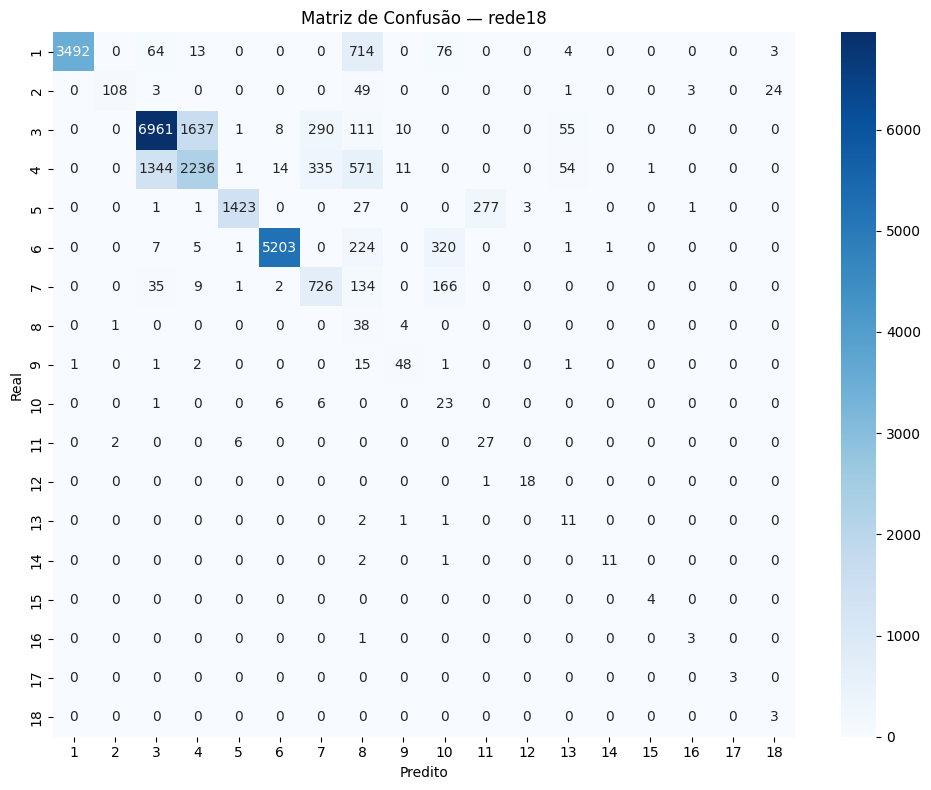

In [15]:
# Matriz de confusão — rede18
labels18 = sorted(set(y_true18) | set(y_pred18))
cm18 = confusion_matrix(y_true18, y_pred18, labels=labels18)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm18, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels18, yticklabels=labels18, ax=ax)
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão — rede18")
plt.tight_layout()
plt.show()

## 11. Composição com Hopfield + PCA (W0plus, wpc, train/test split)

Equivalente a:

```matlab
clo = cl;
clo(~ismember(clo,[1 3 4 5 6 7 0])) = 2;
W0plus = W0 + Wtes70/2;
Wplus  = W0plus * R5k;
wpc    = Wplus * princomp_(Wplus);          % SEM centralização
wtr = [wpc(1:30000,:)     clo(1:30000)];
wts = [wpc(30001:end,:)   clo(30001:end)];
wtr = wtr(wtr(:,end)~=0,:);
wts = wts(wts(:,end)~=0,:);
```

Como `Wtes70` no script vem de `hopf_ts(W0, rede70)` (rede ainda não
treinada nesse momento), aqui usamos `W0teste` (saída da rede18) como
substituto natural; troque por outra rede se preferir.


In [16]:
clo = cl.copy()
mask = ~np.isin(clo, [1, 3, 4, 5, 6, 7, 0])
clo[mask] = 2

# W0plus = W0 + Wtes/2 (mantém escala em [0, 1.5])
W0plus = W0.astype(np.float32) + W0teste.astype(np.float32) / 2.0
Wplus  = W0plus @ R5k

# PCA SEM centralização (princomp_ usa pca(., Centered=false))
P = princomp_(Wplus)
wpc = Wplus @ P                                  # scores não-centrados

# split treino/teste — 30 000 primeiros vs resto
split = 30000
wtr = np.column_stack([wpc[:split],  clo[:split]])
wts = np.column_stack([wpc[split:],  clo[split:]])
wtr = wtr[wtr[:, -1] != 0]
wts = wts[wts[:, -1] != 0]
print(f"wtr: {wtr.shape}, wts: {wts.shape}")


wtr: (22052, 601), wts: (4956, 601)


In [ ]:
# Versão usando apenas o binarizado (sem composição com Hopfield) -- wpc0
# W0swp = Wswp5k (vetores SWeeP pré-computados, equivalente a W0 @ R5k_real)
W0swp    = Wswp5k
bspc5k   = princomp_(W0swp)
wpc0     = W0swp c@ bspc5k                        # sem centralização
wtr0 = np.column_stack([wpc0[:split],  clo[:split]])
wts0 = np.column_stack([wpc0[split:],  clo[split:]])
wtr0 = wtr0[wtr0[:, -1] != 0]
wts0 = wts0[wts0[:, -1] != 0]
print(f"wtr0: {wtr0.shape}, wts0: {wts0.shape}")

wtr0: (22052, 601), wts0: (4956, 601)


## 12. Perfis por subclusters (`perf35`) e `rede35`

Para cada uma das 7 classes em `clo`, roda KMeans com `nc=10` clusters
internos, encontra o representante mais próximo de cada centroide e
guarda o vetor binário original. Resulta em `perf35` com `7 * nc` linhas.


In [18]:
nc = 10
classes_clo = [c for c in [1, 2, 3, 4, 5, 6, 7] if (clo == c).any()]

perf35_list = []
representatives_meta = []   # (classe, idx_global)

for ii in classes_clo:
    idsii  = np.where(clo == ii)[0]
    Wk4    = W0[idsii, :]
    Wswpii = W0swp[idsii, :]

    km = KMeans(n_clusters=nc, n_init=5, random_state=SEED).fit(Wswpii)
    centroids = km.cluster_centers_

    # representante de cada cluster = vetor mais próximo do centroide
    idsgo = np.array([closervects(Wswpii, c, 1) for c in centroids])
    Wgo   = W0[idsii[idsgo], :]
    perf35_list.append(Wgo)
    for j, ig in enumerate(idsgo):
        representatives_meta.append((ii, idsii[ig]))
    print(f"classe {ii}: n={len(idsii):>5d}  "
          f"soma por representante = {Wgo.sum(axis=1).tolist()}")

perf35 = np.vstack(perf35_list).astype(np.float32)
print(f"perf35 shape: {perf35.shape}")

# W35 = (perf35*R5k)*bspc5k -- projeção dos perfis no espaço de PCs
W35 = (perf35 @ R5k) @ bspc5k

# rede35
rede35 = ModernHopfieldNetwork(beta=8.0, n_iters=1, binary=True).to(device)
rede35.store(perf35)
print(f"rede35: {rede35.patterns.shape}")


classe 1: n= 4366  soma por representante = [2208.0, 650.0, 2639.0, 1910.0, 1370.0, 1735.0, 1169.0, 2960.0, 2058.0, 462.0]
classe 2: n=  433  soma por representante = [313.0, 2064.0, 2853.0, 2537.0, 1387.0, 3062.0, 1008.0, 1261.0, 1357.0, 2160.0]
classe 3: n= 9073  soma por representante = [4070.0, 2596.0, 2565.0, 4047.0, 3697.0, 3771.0, 1613.0, 4073.0, 3826.0, 3341.0]
classe 4: n= 4567  soma por representante = [3361.0, 2248.0, 2357.0, 3156.0, 1377.0, 4155.0, 3250.0, 487.0, 3192.0, 2534.0]
classe 5: n= 1734  soma por representante = [464.0, 1573.0, 929.0, 343.0, 929.0, 2088.0, 1177.0, 394.0, 1473.0, 929.0]
classe 6: n= 5762  soma por representante = [2012.0, 1491.0, 506.0, 382.0, 2647.0, 867.0, 1726.0, 1948.0, 1053.0, 1375.0]
classe 7: n= 1073  soma por representante = [1737.0, 923.0, 2885.0, 1781.0, 1382.0, 2968.0, 3449.0, 1930.0, 474.0, 2410.0]
perf35 shape: (70, 5000)
rede35: torch.Size([70, 5000])


## 13. Teste da `rede35` numa subclasse (ex.: `clo == 3`)

```matlab
Wk4  = wsort(W0(clo==3, :));   % EMBARALHA aleatoriamente as linhas
Wtes = hopf_ts(Wk4(1:1000,:), rede35);
```

Como `wsort` é embaralhamento aleatório, `Wk4(1:1000,:)` é uma amostra
aleatória de tamanho 1000 de `W0[clo==3]`.


In [19]:
Wk4   = wsort(W0[clo == 3])      # embaralha aleatoriamente as linhas
n_test = min(1000, Wk4.shape[0])
t0 = time.time()
Wtes  = rede35.retrieve(Wk4[:n_test], batch_size=4096)
print(f"hopf_ts(Wk4[:{n_test}], rede35): {time.time() - t0:.1f}s")

# Como Wk4 foi filtrado por (clo == 3), toda amostra testada tem rótulo 3.
# (No MATLAB original `clo(ii)` parecia usar índice global, o que era
#  aparentemente um bug — aqui consertamos.)
TRUE_CLASS = 3

u = Wtes
rst35 = np.empty((u.shape[0], 5), dtype=np.int64)
for ii in range(u.shape[0]):
    clii = closervects(perf35, u[ii], 1)        # protótipo mais próximo
    classe_predita = clii // nc + 1              # qual das 7 classes
    rst35[ii] = [ii,
                 TRUE_CLASS,
                 classe_predita,
                 int(perf35[clii].sum()),
                 int(u[ii].sum())]

acc35 = (rst35[:, 1] == rst35[:, 2]).mean()
print(f"Acurácia da rede35 (subset clo==3): {acc35 * 100:.2f}%")


hopf_ts(Wk4[:1000], rede35): 0.0s
Acurácia da rede35 (subset clo==3): 92.40%


## 13b. Métricas de avaliação — rede35

Matriz de confusão, F1 score e erro médio para a `rede35` sobre o subconjunto
testado (`clo == 3`). Como todos os rótulos verdadeiros são 3, a matriz mostra
quantas amostras foram corretamente atribuídas à classe 3 vs. outras classes.

In [20]:
y_true35 = rst35[:, 1]
y_pred35 = rst35[:, 2]

acc35_m        = (y_true35 == y_pred35).mean()
erro_medio35   = 1.0 - acc35_m
f1_macro35     = f1_score(y_true35, y_pred35, average="macro",    zero_division=0)
f1_weighted35  = f1_score(y_true35, y_pred35, average="weighted", zero_division=0)

print(f"=== Métricas rede35  (subconjunto clo==3, n={len(y_true35)}) ===")
print(f"  Acurácia       : {acc35_m*100:.2f}%")
print(f"  Erro médio     : {erro_medio35*100:.2f}%")
print(f"  F1 macro       : {f1_macro35:.4f}")
print(f"  F1 ponderado   : {f1_weighted35:.4f}")
print()
print(classification_report(y_true35, y_pred35, zero_division=0))

=== Métricas rede35  (subconjunto clo==3, n=1000) ===
  Acurácia       : 92.40%
  Erro médio     : 7.60%
  F1 macro       : 0.3202
  F1 ponderado   : 0.9605

              precision    recall  f1-score   support

           3       1.00      0.92      0.96      1000
           4       0.00      0.00      0.00         0
           7       0.00      0.00      0.00         0

    accuracy                           0.92      1000
   macro avg       0.33      0.31      0.32      1000
weighted avg       1.00      0.92      0.96      1000



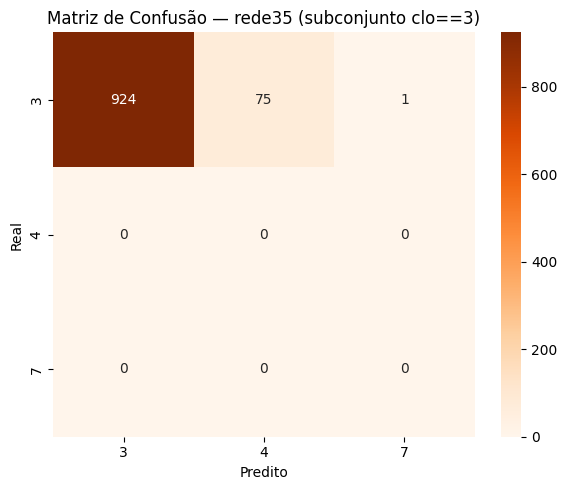

In [21]:
# Matriz de confusão — rede35 (subconjunto clo==3)
labels35 = sorted(set(y_true35) | set(y_pred35))
cm35 = confusion_matrix(y_true35, y_pred35, labels=labels35)

fig, ax = plt.subplots(figsize=(max(6, len(labels35)), max(5, len(labels35))))
sns.heatmap(cm35, annot=True, fmt="d", cmap="Oranges",
            xticklabels=labels35, yticklabels=labels35, ax=ax)
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_title("Matriz de Confusão — rede35 (subconjunto clo==3)")
plt.tight_layout()
plt.show()

## 14. Aplicar `rede35` ao conjunto 5k completo

`Wtes70 = hopf_ts(W0, rede35)` — recupera o padrão de protótipo mais próximo
para **todas** as 40 913 células. Com a GPU RTX 3060 leva poucos minutos.

In [22]:
APPLY_FULL = True

if APPLY_FULL:
    t0 = time.time()
    Wtes70 = rede35.retrieve(W0, batch_size=4096)
    print(f"rede35 sobre todo W0: {time.time() - t0:.1f}s "
          f"-> shape {Wtes70.shape}")


rede35 sobre todo W0: 4.2s -> shape (40913, 5000)


## 14b. Análise do resultado completo — rede35

Para cada célula em `Wtes70`, encontra o protótipo mais próximo em `perf35`
(distância euclidiana vetorizada) e mapeia ao rótulo de classe correspondente.
Em seguida computa matriz de confusão, F1 e erro médio em relação a `clo`.

In [23]:
if APPLY_FULL:
    # Distância euclidiana vetorizada: Wtes70 (n,5000) vs perf35 (70,5000)
    perf35_f = perf35.astype(np.float64)
    Wtes70_f = Wtes70.astype(np.float64)

    a2 = (Wtes70_f ** 2).sum(axis=1, keepdims=True)    # (n, 1)
    b2 = (perf35_f ** 2).sum(axis=1, keepdims=True).T  # (1, 70)
    clii_all = (a2 + b2 - 2 * (Wtes70_f @ perf35_f.T)).argmin(axis=1)

    # Protótipo clii → classe: classes_clo[clii // nc]
    classes_arr  = np.array(classes_clo)
    pred_full70  = classes_arr[clii_all // nc]

    # Métricas (apenas células com rótulo conhecido)
    mask_full    = clo != 0
    y_true_f70   = clo[mask_full]
    y_pred_f70   = pred_full70[mask_full]

    acc_f70       = (y_true_f70 == y_pred_f70).mean()
    erro_f70      = 1.0 - acc_f70
    f1_macro_f70  = f1_score(y_true_f70, y_pred_f70, average="macro",    zero_division=0)
    f1_w_f70      = f1_score(y_true_f70, y_pred_f70, average="weighted", zero_division=0)

    print(f"=== Métricas rede35 — conjunto completo (n={mask_full.sum():,}) ===")
    print(f"  Acurácia     : {acc_f70*100:.2f}%")
    print(f"  Erro médio   : {erro_f70*100:.2f}%")
    print(f"  F1 macro     : {f1_macro_f70:.4f}")
    print(f"  F1 ponderado : {f1_w_f70:.4f}")
    print()
    print(classification_report(y_true_f70, y_pred_f70, zero_division=0))
else:
    print("Execute a célula acima com APPLY_FULL = True primeiro.")

=== Métricas rede35 — conjunto completo (n=27,008) ===
  Acurácia     : 93.03%
  Erro médio   : 6.97%
  F1 macro     : 0.8660
  F1 ponderado : 0.9350

              precision    recall  f1-score   support

           1       1.00      0.94      0.97      4366
           2       0.32      0.64      0.43       433
           3       0.97      0.92      0.94      9073
           4       0.84      0.91      0.88      4567
           5       0.92      0.97      0.95      1734
           6       1.00      0.96      0.98      5762
           7       0.88      0.96      0.92      1073

    accuracy                           0.93     27008
   macro avg       0.85      0.90      0.87     27008
weighted avg       0.94      0.93      0.94     27008



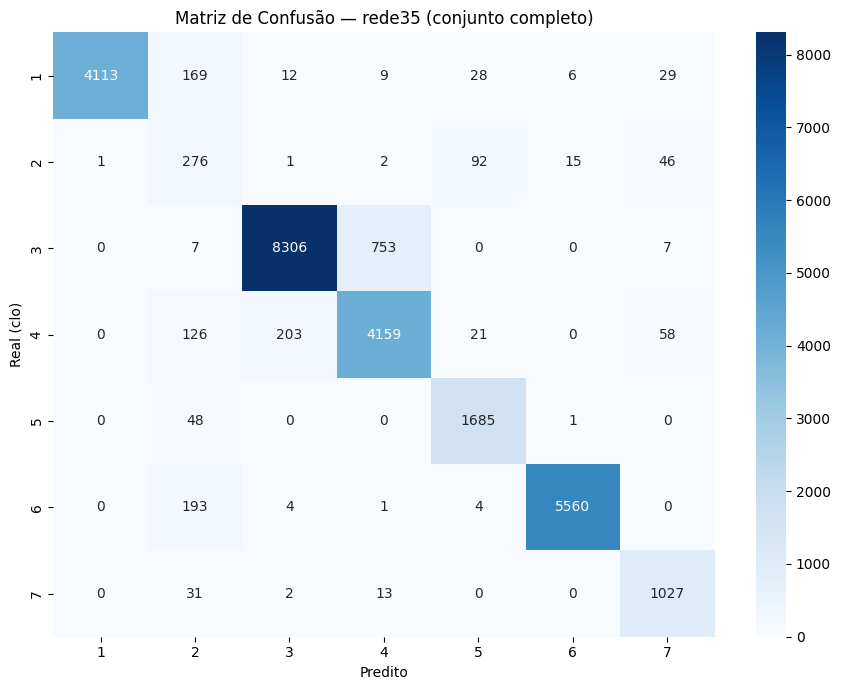

In [24]:
if APPLY_FULL:
    labels_f70 = sorted(set(y_true_f70) | set(y_pred_f70))
    cm_f70 = confusion_matrix(y_true_f70, y_pred_f70, labels=labels_f70)

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(cm_f70, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_f70, yticklabels=labels_f70, ax=ax)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real (clo)")
    ax.set_title("Matriz de Confusão — rede35 (conjunto completo)")
    plt.tight_layout()
    plt.show()
else:
    print("Execute a célula de recuperação com APPLY_FULL = True primeiro.")

## 15. Notas finais

* **Hiperparâmetros da Modern Hopfield**: `beta` controla a nitidez da
  recuperação. Para padrões muito esparsos / de alta dimensão, valores
  entre 4 e 16 costumam funcionar; experimente.
* Se quiser comparar com a Hopfield clássica, basta criar uma classe
  análoga com regra de Hebb (`W = (1/N) Σ ξ_i ξ_iᵀ`, diagonal zerada)
  e atualização síncrona/assíncrona com `sign`.
* Funções auxiliares: todas (`sorti`, `princomp_`, `closervects`,
  `contaocorr`, `mat2celllines`, `wsort`, `indexa`) seguem fielmente
  os arquivos `.m` originais. Em particular, `princomp_` **não centra**
  os dados e `wsort` é um embaralhamento aleatório.
* **rSWeeP** (R5k): a base ortonormal vem do AIBIALab —
  https://aibialab.github.io/rSWeeP.html. As células 4b/4c validam a
  ortonormalidade e oferecem um substituto sintético via QR para testes.
  O fluxo separa intencionalmente *espaço binário* (onde a Hopfield
  armazena padrões) de *espaço SWeeP* (onde K-means e busca por
  vizinhos operam).
* Persistência: salve modelos com
  `torch.save({"patterns": rede35.patterns.cpu()}, "rede35.pt")`.
